In [311]:
f06 = open("gtg-jun.txt", "r", encoding="utf8").read()
f07 = open("gtg-jul.txt", "r", encoding="utf8").read()
f08 = open("gtg-august.txt", "r", encoding="utf8").read()
f09 = open("gtg-september.txt", "r", encoding="utf8").read()
f10 = open("gtg-oktober.txt", "r", encoding="utf8").read()
f11 = open("gtg-november.txt", "r", encoding="utf8").read()
f12 = open("gtg-december.txt", "r", encoding="utf8").read()

fulltext = '\n'.join([f07, f08, f09, f10, f11, f12])

f = open("games.js", "r", encoding="utf8")
games_file = f.read()

In [312]:
import json
import pandas as pd
import re

with open('games.json', encoding="utf8") as file:
    d=json.loads(file.read())

new_games_df = pd.DataFrame.from_dict(d).T.drop(['affiliate_links', 'backloggd_link', 'content', 'submitted_by', 'twitter_ids'], axis=1)
new_games_df["game"] = new_games_df['answers'].apply(lambda x: x[0])
new_games_df = new_games_df.drop(['answers'], axis=1)

def clear_platforms(x):
    x = re.sub(r'\(.*\)', '', x)
    if x.startswith('2020: PC'):
        return ['PC']
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip() for s in x]
    x = ["PS1" if s == "PS" else s for s in x]
    x = ["X360" if s == "360" else s for s in x]
    x = ["GameCube" if s == "Gamecube" else s for s in x]
    x = ["Xbox Series" if s == "X Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Xbox series" else s for s in x]
    x = ["Mac" if s == "Macintosh" else s for s in x]
    return x

new_games_df["console_platform"] = new_games_df["console_platform"].apply(clear_platforms)

def clear_genres(x):
    x = re.sub(r'\(.*\)', '', x)
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip().casefold() for s in x]
    return x

new_games_df["genre"] = new_games_df["genre"].apply(clear_genres)

def clear_metacritic(x):
    if x and x[0].isalpha():
        return None
    x = re.search(r"[0-9]+", x)
    return x.group(0)

new_games_df["metacritic_score"] = new_games_df["metacritic_score"].apply(clear_metacritic)
new_games_df["metacritic_score"] = new_games_df["metacritic_score"].astype(float)

new_games_df["release_year"] = new_games_df["release_year"].apply(lambda x: re.search(r"[0-9]{4}", x).group(0))
new_games_df["release_year"] = new_games_df["release_year"].astype(int)

new_games_df["day"] = new_games_df.index.astype(int)
new_games_df = new_games_df.set_index('day')

In [313]:
import re

pasted = re.findall(".* — [^#—]+#GuessTheGame #[0-9]*\n\n🎮 [🟥🟨🟩⬜ ]{11}|#GuessTheGame #[0-9]*\n\n🎮 [🟥🟨🟩⬜ ]{11}", fulltext)
games = re.findall('answers: \["[^"]*', games_file)
pasted_all = re.findall("#GuessTheGame #[0-9]*\n\n🎮 [🟥🟨🟩⬜ ]{11}", fulltext)

In [315]:
import pandas as pd
import numpy as np

df = pd.DataFrame(pasted, columns=['full'])
df['name'] = df['full'].apply(lambda x: x.split(" — ")[0]  if "—" in x else None)

df['day'] = df['full'].apply(lambda x: re.findall("#[0-9]+", x)[0][1:])
df['day'] = df['day'].astype(int)

df['guess'] = df['full'].apply(lambda x: re.findall("[🟥🟨🟩⬜]", x).index("🟩") if "🟩" in re.findall("[🟥🟨🟩⬜]", x) else np.nan)

df['score'] = ((df['guess']) * -1) + 6
df['score'].loc[np.isnan(df['score'])] = 0

df['days played'] = 1

df['guess'] = df['guess'] + 1

df['guess'].loc[np.isnan(df['guess'])] = 7

df = df.ffill()

In [335]:
#df = df[(df.day >= 932) & (df.day <= 962)]
len(df)

2697

In [317]:
difficulty_index = df.groupby(['day']).agg({'score':'mean'}).sort_values(by='score')
difficulty_index = difficulty_index.rename(columns={"score": "day_difficulty"})

df = df.join(difficulty_index, on='day')

df['AW hipster score'] = df['score'] / df['day_difficulty']

In [318]:
df = df.join(new_games_df, on='day')

In [339]:
df['decade'] = df['release_year'].apply(lambda x: x // 10 * 10)

In [296]:
df = df[df.genre.apply(lambda x: ('turn based' in x) or ('jrpg' in x))]
len(df)

142

In [342]:
df = df[df.release_year >= 1980]
len(df)

2665

In [259]:
df = df[(df.developer == 'Nintendo EAD') | (df.developer == 'Capcom') | (df.developer == 'Nintendo') | (df.developer == 'Capcom Co., Ltd.') | (df.developer == 'Nintendo EPD') | (df.developer == 'Namco')
        | (df.developer == 'Nintendo R&D1') | (df.developer == 'Square') | (df.developer == 'Square Enix') | (df.developer == 'Sega') | (df.developer == 'Sonic Team') | (df.developer == 'FromSoftware, Inc.')
        | (df.developer == 'FromSoftware') | (df.developer == 'Atlus') | (df.developer == 'Japan Studio') | (df.developer == 'Namco Limited') | (df.developer == 'Platinum Games Inc.') | (df.developer == 'PlatinumGames')
        | (df.developer == 'Kojima Productions') | (df.developer == 'Konami Computer Entertainment Japan') | (df.developer == 'Konami Computer Entertainment Tokyo')]
len(df)

0

In [382]:
decades = df.groupby(['name', 'decade']).agg({'score':'mean', 'days played':'sum'}).sort_values('score', ascending=False).reset_index()
decades = decades[decades["days played"] > 10].drop_duplicates("name")
decades = decades[decades["days played"] > 5][['name', 'decade']]
decades['top_decade'] = decades['decade'].astype(str).apply(lambda x: x + "s")
decades = decades.drop('decade', axis=1)
decades = decades.sort_values('name')
decades.set_index('name')

,top_decade
name,
Alex,1990s
Celo,1990s
Hades🐍,2010s
HusKy,2010s
Joey Vancouver,1990s
Norrack,1990s
Ratpike,2010s
Shape1ess,1990s
Tulex,1990s


In [332]:
df_final = df.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by='score', ascending=False)
df_final['guess'] = df_final['guess'].round(2)
df_final = df_final.rename(columns={"guess": "mean correct guess", "score": "total score"})
df_final['median correct guess'] = df.groupby(['name']).agg({'guess':'median'}).astype(int)
df_final["total score"] = df_final["total score"].astype(int)
df_final = df_final.reset_index()
df_final.index += 1
df_final

,name,total score,days played,mean correct guess,median correct guess
1,yablko,642,184,3.51,3
2,boomer,526,183,4.13,4
3,Hades🐍,519,184,4.18,4
4,Joey Vancouver,513,184,4.21,4
5,Alex,423,178,4.62,5
6,hostinko,396,181,4.81,5
7,Shape1ess,392,183,4.86,5
8,Celo,375,182,4.94,5
9,HusKy,348,115,3.97,4
10,ghst0,323,89,3.37,3


In [308]:
hipster_score = df.copy().sort_values('AW hipster score', ascending=False).drop_duplicates(['name'])[['name', 'day', 'guess', 'AW hipster score']]
hipster_score['day'] = hipster_score['day'].astype("Int64")
hipster_score["guess"] = hipster_score["guess"].astype(int)
hipster_score = hipster_score.join(new_games_df[['game', 'release_year']], on='day')
hipster_score['AW hipster score'] = hipster_score['AW hipster score'].round(2)
hipster_score.index = range(len(hipster_score))
hipster_score.index += 1
hipster_score

,name,day,guess,AW hipster score,game,release_year
1,Armed Crab,944,1,16.00,Helltaker,2020
2,boomer,911,4,15.00,Shadow Hearts: Covenant,2004
3,Tulex,907,6,15.00,Vagrant Story,2000
4,myster,861,4,15.00,The Journeyman Project,1993
5,ghst0,956,2,14.00,Once Human,2024
6,fun3s,834,4,13.00,Champions of Norrath,2004
7,Hades🐍,924,5,13.00,Gauntlet: Legends,1998
8,yablko,868,5,12.00,Metal Arms: Glitch in the System,2003
9,Norrack,831,5,8.67,"Hey You, Pikachu!",1998
10,HusKy,921,4,7.50,Spectre Divide,2024


In [113]:
difficulty_index.join(new_games_df['game'], on='day').head(10)

,day_difficulty,game
day,,
897,0.000000,Brute Force
949,0.000000,Eternal Ring
907,0.066667,Vagrant Story
847,0.071429,Monster Hunter: Stories
924,0.153846,Gauntlet: Legends
813,0.153846,Exit 8
868,0.166667,Metal Arms: Glitch in the System
911,0.200000,Shadow Hearts: Covenant
861,0.200000,The Journeyman Project


In [114]:
difficulty_index.join(new_games_df['game'], on='day').sort_values(by='day_difficulty', ascending=False).head(10)

,day_difficulty,game
day,,
852,5.875000,Grand Theft Auto
961,5.705882,pong
880,5.400000,Super Mario Kart
849,5.375000,The Sims 2
879,5.333333,Ori and the Will of the Wisps
934,5.117647,Mirror's Edge Catalyst
804,4.933333,Space Invaders
959,4.764706,A Short Hike
807,4.733333,Kingdom Come: Deliverance


In [20]:
import matplotlib.pyplot as plt

import numpy as np

from sklearn import datasets, decomposition

df_final = df.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by='score', ascending=False)
df_final['guess'] = df_final['guess'].round(2)
df_final = df_final.rename(columns={"guess": "mean correct guess", "score": "total score"})
df_final['median correct guess'] = df.groupby(['name']).agg({'guess':'median'}).astype(int)
df_final["total score"] = df_final["total score"].astype(int)
df_final = df_final.reset_index()
df_final.index += 1
df_final

,name,total score,days played,mean correct guess,median correct guess
1,yablko,667,184,3.38,3
2,boomer,529,182,4.09,4
3,Hades🐍,524,184,4.15,4
4,Joey Vancouver,513,184,4.21,4
5,Alex,413,164,4.48,5
6,myster,379,98,3.13,3
7,Shape1ess,378,181,4.91,5
8,hostinko,368,178,4.93,6
9,Celo,324,164,5.02,5
10,HusKy,314,98,3.80,3


In [69]:
hracikovia = list(df_final.name[df_final["days played"] >= 60])

In [71]:
to_pivot = df[df.name.isin(hracikovia)][["name", "score", "game"]]

In [72]:
pivoted = to_pivot.pivot_table(index="name", columns="game", values="score")

In [30]:
#pivoted = to_pivot.pivot_table(index="game", columns="name", values="score")

In [73]:
pivoted = pivoted.fillna(value=0)

In [74]:
pca = decomposition.PCA(n_components=3)
pca.fit(pivoted)
pca_X = pca.transform(pivoted)

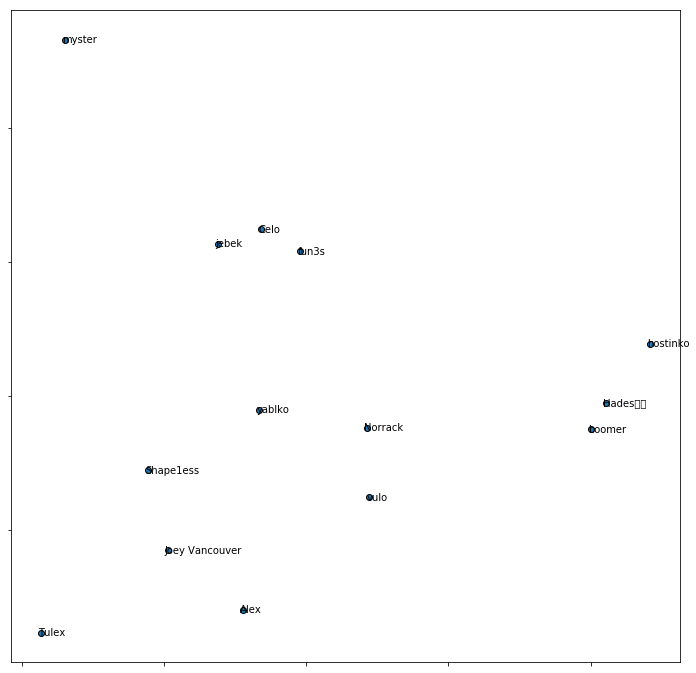

In [75]:
fig = plt.figure(1, figsize=(12, 12))
plt.clf()

ax = fig.add_subplot(111)

ax.scatter(pca_X[:, 1], pca_X[:, 2], edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

for i, txt in enumerate(pivoted.index):
    ax.annotate(pivoted.index[i], (pca_X[i, 1] - 0.1, pca_X[i, 2] - 0.1))

plt.show()

In [76]:
hracikovia_data = df_final.set_index('name').loc[pivoted.index]

In [77]:
hracikovia_data

,total score,days played,mean correct guess,median correct guess
name,,,,
Alex,279,104,4.32,4
Celo,192,103,5.14,6
Hades🐍,344,123,4.20,4
Joey Vancouver,340,123,4.24,4
Norrack,136,93,5.54,6
Shape1ess,247,120,4.94,5
Tulex,184,87,4.89,5
boomer,350,121,4.11,4
fun3s,151,122,5.76,7


In [83]:
import matplotlib
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#FDD640","#EF4A46"])

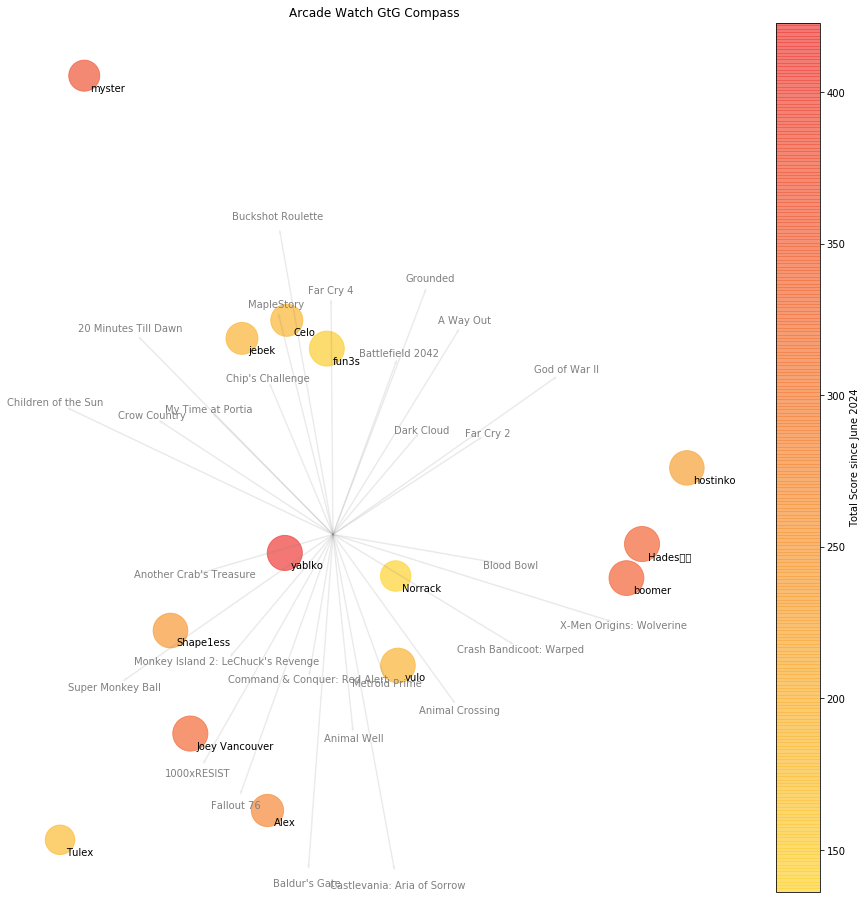

In [104]:
def myplot(score,coeff,labels=None):
    fig = plt.figure(1, figsize=(16, 16))
    plt.clf()

    ax = fig.add_subplot(111)

    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    sc = ax.scatter(xs * scalex,ys * scaley, c=hracikovia_data['total score'], s=hracikovia_data['days played'] * 10, cmap=cmap, alpha=0.75)
    for i, txt in enumerate(pivoted.index):
        ax.annotate(txt, (xs[i] * scalex + 0.01, ys[i] * scaley - 0.02))

    for i in range(n):
        if ((coeff[i,0]**2 + coeff[i,1]**2)**0.5) > 0.10:
            draw = True
            for j in range(i):
                if (((coeff[j,0]-coeff[i,0])**2 + (coeff[i,1]-coeff[j,1])**2)**0.5) < 0.04:
                    draw = False
                    break
            if draw == False:
                continue
            ax.arrow(0, 0, coeff[i,0] * 1.75, coeff[i,1] * 1.75,color = 'gray',alpha = 0.1)
            if labels is None:
                ax.text(coeff[i,0]* 1.85, coeff[i,1] * 1.85, "Var"+str(i+1), color = 'gray', ha = 'center', va = 'center')
            else:
                ax.text(coeff[i,0]* 1.85, coeff[i,1] * 1.85, labels[i], color = 'gray', ha = 'center', va = 'center')

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])

    return sc



#Call the function. Use only the 2 PCs.
sc = myplot(pca_X[:,1:3],np.transpose(pca.components_[1:3]), labels=pivoted.columns)
#plt.xlim(-0.6, 0.6)
#plt.ylim(-0.6, 0.6)
plt.colorbar(sc, label='Total Score since June 2024')
#plt.grid()
plt.axis('off')
plt.title("Arcade Watch GtG Compass")
plt.show()